# 01 — Korpus & Annotation

Phase 1 (Korpus + Bias-Notiz) und Phase 2 (κ + drei Edge Cases) leben in diesem Notebook. Pipeline → `02_extract.ipynb`, Eval → `03_eval.ipynb`, Frontier → `04_frontier_compare.ipynb`.

## Phase 1 — Korpus inspizieren + Bias-Notiz

In [1]:
import requests
import json
import base64
import time
import os

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36 Edg/147.0.0.0",
    "X-API-Key": "jobboerse-jobsuche",
}

### Parameter-Übersicht

| Parameter | Typ | Werte / Format | Beschreibung |
|---|---|---|---|
| `was` | string | Freitext | Jobtitel, z.B. `Data Scientist` |
| `wo` | string | Freitext | Beschäftigungsort, z.B. `Bremen` |
| `umkreis` | int | km, sinnvoll 0–200 | Suchradius um `wo` |
| `berufsfeld` | string | Freitext | z.B. `Informatik`, `Wirtschaft` |
| `arbeitgeber` | string | Freitext | exakter Firmenname |
| `veroeffentlichtseit` | int | **0–100** Tage | Tage seit Veröffentlichung |
| `angebotsart` | int | `1` · `2` · `4` · `34` | Art der Stelle (siehe unten) |
| `befristung` | int / string | `1` · `2` · `"1;2"` | Vertragsart (siehe unten) |
| `arbeitszeit` | string | `vz` · `tz` · `snw` · `ho` · `mj` | Arbeitszeitmodell, mehrere via `;` (siehe unten) |
| `zeitarbeit` | string | `"true"` / `"false"` | Zeitarbeitsfirmen ein-/ausschließen (Default: `true`) |
| `behinderung` | string | `"true"` / `"false"` | Schwerbehinderten-Vermittlung |
| `corona` | string | `"true"` / `"false"` | nur Corona-Kontext-Jobs |
| `size` | int | **1–100** | Treffer pro Seite |
| `page` | int | 1, 2, 3, … | Pagination |

### Werte-Tabellen

**`angebotsart`** — Art der Stelle:

| Wert | Bedeutung |
|---|---|
| `1` | Arbeit (Standard-Arbeitsstelle) |
| `2` | Selbstständigkeit |
| `4` | Ausbildung / Duales Studium |
| `34` | Praktikum / Trainee |

**`befristung`** — Vertragsart (Mehrfachwerte mit `;`):

| Wert | Bedeutung |
|---|---|
| `1` | befristet |
| `2` | unbefristet |
| `"1;2"` | beide |

**`arbeitszeit`** — Arbeitszeitmodell (Mehrfachwerte mit `;`):

| Wert | Bedeutung |
|---|---|
| `vz` | Vollzeit |
| `tz` | Teilzeit |
| `snw` | Schicht / Nacht / Wochenende |
| `ho` | Heim- / Telearbeit (Homeoffice) |
| `mj` | Minijob |
| `"vz;tz"` | Kombination: Voll- + Teilzeit |
| `"vz;tz;ho"` | Kombination: Voll- + Teilzeit + Homeoffice |

In [2]:
# Standard-Parameter für alle Suchen.
# Werden ggf. pro Suchanfrage überschrieben.
basis_parameter = {           
    "size": 50,                  # max. Treffer pro Seite (max. 100)
    "veroeffentlichtseit": 100,  # Anzeigen aus den letzten N Tagen
    "zeitarbeit": "false",       # Zeitarbeitsfirmen ausschließen
    "befristung": "1;2",         # 1 = befristet, 2 = unbefristet → beide
    "arbeitszeit": "vz;tz",      # vz = Vollzeit, tz = Teilzeit → beide
    "behinderung": "false",
    "corona": "false",
    "umkreis": 100,
}

# Suchbegriffe + optionale Overrides pro Anfrage.
# "Data Scientist" läuft enger (Informatik, 50 km, nur Vollzeit + unbefristet).
# Alle anderen nutzen die Defaults aus basis_parameter.

such_anfragen = [
    {"was": "Data Scientist", "wo": "Bremen"},
    {"was": "Business Analyst", "wo": "Hannover"},
    {"was": "Data Analyst", "wo": "Hamburg"},
    {"was": "Datenanalyse", "wo": "Bremen"},
    {"was": "Data Engineer", "wo": "Bremen"},
    {"was": "Machine Learning", "wo": "Bremen"},
    {"was": "Künstliche Intelligenz", "wo": "Bremen"},
    {"was": "Künstliche Intelligenz", "wo": "Münster"},
    {"was": "Ausbildung zum Fachinformatiker", "wo": "Bremen"},
]

url_suche = "https://rest.arbeitsagentur.de/jobboerse/jobsuche-service/pc/v4/jobs"

refnr_liste = []
for anfrage in such_anfragen:
    parameter = {**basis_parameter, **anfrage}   # Overrides gewinnen
    response = requests.get(url_suche, params=parameter, headers=headers, timeout=10)
    
    treffer = response.json().get("maxErgebnisse", 0) if response.status_code == 200 else "–"
    print(f"[{anfrage['was']:25}] Status {response.status_code}  Treffer: {treffer}")
    
    if response.status_code == 200:
        for stelle in response.json().get("stellenangebote", []):
            refnr_liste.append(stelle["refnr"])
    
    time.sleep(0.3)   # Pause zwischen Suchanfragen

# Duplikate entfernen
refnr_liste = list(set(refnr_liste))
print(f"\nEindeutige refnrs gesamt: {len(refnr_liste)}")

[Data Scientist           ] Status 200  Treffer: 4
[Business Analyst         ] Status 200  Treffer: 13
[Data Analyst             ] Status 200  Treffer: 13
[Datenanalyse             ] Status 200  Treffer: 18
[Data Engineer            ] Status 200  Treffer: 20
[Machine Learning         ] Status 200  Treffer: 41
[Künstliche Intelligenz   ] Status 200  Treffer: 19
[Künstliche Intelligenz   ] Status 200  Treffer: 16
[Ausbildung zum Fachinformatiker] Status 200  Treffer: 55

Eindeutige refnrs gesamt: 165


In [3]:
url_details = "https://rest.arbeitsagentur.de/jobboerse/jobsuche-service/pc/v4/jobdetails"

job_details_liste = []
for index, refnr in enumerate(refnr_liste, start=1):
    encoded_refnr = base64.b64encode(refnr.encode("utf-8")).decode("utf-8")
    
    response = requests.get(f"{url_details}/{encoded_refnr}", headers=headers, timeout=10)
    
    if response.status_code == 200:
        job_data = response.json()
        eintrag = {
            "refnr": refnr,
            "titel": job_data.get("stellenangebotsTitel", ""),
            "firma": job_data.get("arbeitgeber", job_data.get("firma", "")),
            "text":  job_data.get("stellenangebotsBeschreibung", ""),
            "ort": job_data.get("stellenlokationen", [{}])[0].get("adresse", {}).get("ort", ""),
        }
        job_details_liste.append(eintrag)
    elif response.status_code == 429:
        # Rate Limit getroffen → länger warten, refnr überspringen
        print(f"  Rate Limit bei {refnr} → warte 5s")
        time.sleep(5)
        continue
    else:
        print(f"  Fehler {refnr}: Status {response.status_code}")
    
    if index % 25 == 0:
        print(f"  {index}/{len(refnr_liste)} verarbeitet")
    
    time.sleep(0.2)   # Pause zwischen Detailabrufen

print(f"\nFertig: {len(job_details_liste)} Jobdetails geladen")

  25/165 verarbeitet
  50/165 verarbeitet
  75/165 verarbeitet
  100/165 verarbeitet
  125/165 verarbeitet
  150/165 verarbeitet

Fertig: 165 Jobdetails geladen


In [5]:
print("--- Struktur von job_data ---")
print(json.dumps(job_data, indent=4, ensure_ascii=False))

--- Struktur von job_data ---
{
    "stellenangebotsart": "ARBEIT",
    "stellenangebotsTitel": "IT-Systemadministrator (m/w/d)",
    "quereinstiegGeeignet": false,
    "stellenangebotsBeschreibung": "IT-Systemadministrator (m/w/d)\n\nFESTANSTELLUNG | APEN\n\nUnser Mandant ist ein etabliertes, international tätiges Unternehmen im Maschinen- und Anlagenbau. Mit jahrzehntelanger Erfahrung in der Entwicklung und Fertigung innovativer Lösungen setzt das Unternehmen Maßstäbe in Qualität, Funktionalität und Anwenderfreundlichkeit. Am Standort in Apen kommen modernste Technologien zum Einsatz, um maßgeschneiderte Produkte für Kunden in verschiedenen Branchen zu realisieren.\n\nIHRE AUFGABEN\n- Sie betreuen und administrieren die IT-Infrastruktur, einschließlich Server, Netzwerke und Endgeräte.\n- Systemupdates, Backups und Sicherheitsprüfungen führen Sie eigenständig durch, um den reibungslosen Betrieb zu gewährleisten.\n- Im First- und Second-Level-Support unterstützen Sie Anwender bei IT-Pr

In [6]:
ausgabe_pfad = "/home/jovyan/work/notebooks/LLM-Workshop/llm-workshop/daten/eigener_korpus.jsonl"
os.makedirs(os.path.dirname(ausgabe_pfad), exist_ok=True)

print(f"Aktuelles Arbeitsverzeichnis: {os.getcwd()}")

with open(ausgabe_pfad, "w", encoding="utf-8") as datei:
    for eintrag in job_details_liste:
        datei.write(json.dumps(eintrag, ensure_ascii=False) + "\n")

print(f"Gespeichert: {len(job_details_liste)} Einträge in {ausgabe_pfad}")

Aktuelles Arbeitsverzeichnis: /home/jovyan/work/notebooks/LLM-Workshop/llm-workshop/notebooks
Gespeichert: 165 Einträge in /home/jovyan/work/notebooks/LLM-Workshop/llm-workshop/daten/eigener_korpus.jsonl


In [7]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

korpus_pfad = "/home/jovyan/work/notebooks/LLM-Workshop/llm-workshop/daten/eigener_korpus.jsonl"

korpus = []
with open(korpus_pfad, "r", encoding="utf-8") as datei:
    for zeile in datei:
        korpus.append(json.loads(zeile))

korpus_df = pd.DataFrame(korpus)
print(f"Anzeigen im Korpus: {len(korpus_df)}")
print(f"Felder insgesamt:   {len(korpus_df.columns)}")
print(f"\nErste 10 Spalten: {list(korpus_df.columns[:10])}")

<jemalloc>: Unsupported system page size


Anzeigen im Korpus: 165
Felder insgesamt:   5

Erste 10 Spalten: ['refnr', 'titel', 'firma', 'text', 'ort']


Beschreibungstexte – Quantile
       text_zeichen  text_woerter
count         165.0         165.0
mean         3619.0         449.0
std          1317.0         167.0
min           899.0         124.0
10%          1971.0         239.0
25%          2598.0         309.0
50%          3527.0         452.0
75%          4605.0         576.0
90%          5335.0         652.0
max          6849.0         982.0

Leere text-Felder:           0
Sehr kurze Anzeigen (< 50 W): 0
Sehr lange Anzeigen (> 800):  3


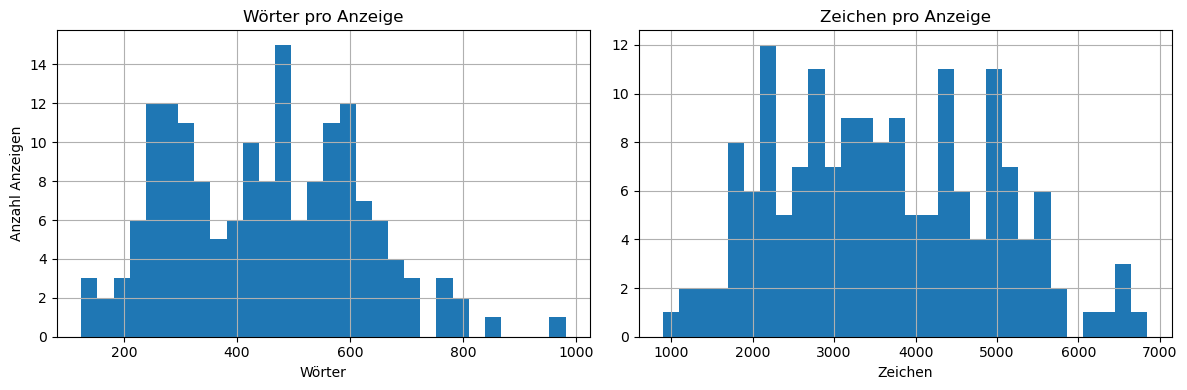

In [8]:
korpus_df["text_zeichen"] = korpus_df["text"].fillna("").str.len()
korpus_df["text_woerter"] = korpus_df["text"].fillna("").str.split().str.len()

print("Beschreibungstexte – Quantile")
print(korpus_df[["text_zeichen", "text_woerter"]]
      .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
      .round(0))

leere_texte = (korpus_df["text_zeichen"] == 0).sum()
sehr_kurz   = (korpus_df["text_woerter"] < 50).sum()
sehr_lang   = (korpus_df["text_woerter"] > 800).sum()

print(f"\nLeere text-Felder:           {leere_texte}")
print(f"Sehr kurze Anzeigen (< 50 W): {sehr_kurz}")
print(f"Sehr lange Anzeigen (> 800):  {sehr_lang}")

abbildung, achsen = plt.subplots(1, 2, figsize=(12, 4))
korpus_df["text_woerter"].hist(bins=30, ax=achsen[0])
achsen[0].set_title("Wörter pro Anzeige")
achsen[0].set_xlabel("Wörter")
achsen[0].set_ylabel("Anzahl Anzeigen")

korpus_df["text_zeichen"].hist(bins=30, ax=achsen[1])
achsen[1].set_title("Zeichen pro Anzeige")
achsen[1].set_xlabel("Zeichen")
plt.tight_layout()
plt.show()

In [9]:
firmen_haeufigkeit = korpus_df["firma"].fillna("(leer)").value_counts()

eindeutige_firmen  = firmen_haeufigkeit.shape[0]
einmal_vertreten   = (firmen_haeufigkeit == 1).sum()
top10_anteil       = firmen_haeufigkeit.head(10).sum() / len(korpus_df)
top3_anteil        = firmen_haeufigkeit.head(3).sum() / len(korpus_df)

print(f"Eindeutige Firmen:               {eindeutige_firmen}")
print(f"Firmen mit nur einer Anzeige:    {einmal_vertreten}  "
      f"({einmal_vertreten / eindeutige_firmen:.0%})")
print(f"Anteil Top-3 Firmen am Korpus:   {top3_anteil:.1%}")
print(f"Anteil Top-10 Firmen am Korpus:  {top10_anteil:.1%}")

print("\nTop 15 Firmen nach Anzeigenzahl:")
print(firmen_haeufigkeit.head(15).to_string())

Eindeutige Firmen:               81
Firmen mit nur einer Anzeige:    61  (75%)
Anteil Top-3 Firmen am Korpus:   29.7%
Anteil Top-10 Firmen am Korpus:  49.7%

Top 15 Firmen nach Anzeigenzahl:
firma
EY Consulting GmbH                 19
BWI GmbH                           17
Piening GmbH Engineering & IT      13
Rheinmetall AG                     10
CHECK24 Services Personal GmbH      7
AMADEUS FIRE AG                     4
Löwenstein Med.Techn.GmbH+Co.KG     3
BridgingIT GmbH                     3
Finanz Informatik GmbH & Co. KG     3
OHB-System AG                       3
Dirk Rossmann GmbH                  3
Technische Universität Hamburg      3
MEYER WERFT GmbH                    2
AirITSystems GmbH                   2
Deloitte GmbH                       2


In [10]:
# Häufige Titel (oft dieselbe Anzeige unter mehreren refnrs)
titel_haeufigkeit = korpus_df["titel"].value_counts()
print(f"Eindeutige Titel: {titel_haeufigkeit.shape[0]}")
print("\nTop 10 Titel:")
print(titel_haeufigkeit.head(10).to_string())

# Senioritäts-Heuristik via Regex auf Titel.
# Reihenfolge wichtig: höhere/spezifischere Stufen zuerst,
# weil der erste Match gewinnt.
senioritaets_muster = {
    "Head/Manager":      r"\b(head of|teamleit|manager|director|leitung)\b",
    "Lead/Principal":    r"\b(lead|principal|chief)\b",
    "Senior":            r"\bsenior\b",
    "Expert/Specialist": r"\b(expert|specialist|spezialist|experte)\b",
    "Junior":            r"\b(junior|berufseinsteig|absolvent)\b",
    "Praktikum/Trainee": r"\b(praktik(um|ant)|trainee|werkstud)",
}

def klassifiziere_seniority(titel: str) -> str:
    titel_klein = (titel or "").lower()
    for stufe, muster in senioritaets_muster.items():
        if re.search(muster, titel_klein):
            return stufe
    return "(unklassifiziert)"

korpus_df["seniority"] = korpus_df["titel"].apply(klassifiziere_seniority)

print("\nVerteilung Senioritätsstufen:")
print(korpus_df["seniority"].value_counts().to_string())

# Sanity-Check: ein paar Beispiel-Titel pro Stufe
print("\nBeispiel-Titel je Stufe:")
for stufe in korpus_df["seniority"].unique():
    beispiele = korpus_df.loc[korpus_df["seniority"] == stufe, "titel"].head(3).tolist()
    print(f"  {stufe}:")
    for titel in beispiele:
        print(f"    – {titel}")

Eindeutige Titel: 147

Top 10 Titel:
titel
Fachinformatiker für Systemintegration (m/w/d)                          7
Servicetechniker im technischen Außendienst (m/w/d)                     4
IT Service Desk Agent (m/w/d) 1st Level                                 3
Senior IT-Administrator (w/m/d)                                         2
Research Associate / Wissenschaftliche*r Mitarbeiter*in at the In...    2
Technischer Produkt Manager (m/w/d) Traineeprogramm Hamburg             2
Associate Product Owner (m/w/d) Traineeprogramm Hamburg                 2
Senior IT Expert Plattform Automation (m/w/d)                           2
IT-Security Administratorin (m/w/d)                                     2
Fachinformatiker Anwendungsentwicklung (m/w/d)                          2

Verteilung Senioritätsstufen:
seniority
(unklassifiziert)    106
Senior                26
Head/Manager          11
Praktikum/Trainee      8
Expert/Specialist      7
Lead/Principal         5
Junior                 2



In [11]:
def ist_befuellt(wert) -> bool:
    """True, wenn Wert nicht None, nicht leerer String/Liste/Dict."""
    if wert is None:
        return False
    if isinstance(wert, (str, list, dict)) and len(wert) == 0:
        return False
    return True

coverage = pd.DataFrame({
    "feld": korpus_df.columns,
    "befuellt_anzahl": [korpus_df[feld].apply(ist_befuellt).sum()
                        for feld in korpus_df.columns],
})
coverage["befuellt_quote"] = coverage["befuellt_anzahl"] / len(korpus_df)
coverage = coverage.sort_values("befuellt_quote", ascending=False).reset_index(drop=True)

kern_felder    = (coverage["befuellt_quote"] >= 0.95).sum()
seltene_felder = (coverage["befuellt_quote"] <  0.10).sum()

print(f"Felder im Korpus insgesamt:                  {len(coverage)}")
print(f"Kern-Felder (≥ 95% befüllt):                  {kern_felder}")
print(f"Sehr seltene Felder (< 10% befüllt):          {seltene_felder}")

print("\n— Top 20 Felder (höchste Coverage) —")
print(coverage.head(20).to_string(index=False))

print("\n— Bottom 10 Felder (niedrigste Coverage) —")
print(coverage.tail(10).to_string(index=False))

Felder im Korpus insgesamt:                  8
Kern-Felder (≥ 95% befüllt):                  8
Sehr seltene Felder (< 10% befüllt):          0

— Top 20 Felder (höchste Coverage) —
        feld  befuellt_anzahl  befuellt_quote
       refnr              165             1.0
       titel              165             1.0
       firma              165             1.0
        text              165             1.0
         ort              165             1.0
text_zeichen              165             1.0
text_woerter              165             1.0
   seniority              165             1.0

— Bottom 10 Felder (niedrigste Coverage) —
        feld  befuellt_anzahl  befuellt_quote
       refnr              165             1.0
       titel              165             1.0
       firma              165             1.0
        text              165             1.0
         ort              165             1.0
text_zeichen              165             1.0
text_woerter              165          

### Bias- Notiz

Der Korpus hat ein paar methodische Einschränkungen, da die Daten ausschließlich aus der API der Bundesagentur für Arbeit stammen. Dadurch fehlen Start-ups und internationale Unternehmen, die eher auf LinkedIn oder Xing ausschreiben, während rein deutsche Rollenbezeichnungen wie „Datenanalytiker“ durch die Fokussierung auf englische Buzzwords unterrepräsentiert sind. Zudem ist die Untersuchung geografisch fest auf die Regionen Bremen, Hamburg, Hannover und Münster im 100-km-Radius begrenzt, sodass überregionale Jobs oder reine Remote-Stellen kaum erfasst werden. Ein weiteres Problem ist die starke Firmenkonzentration: Die Top-3-Unternehmen machen bereits knapp 30 % des Korpusses aus, und die Top-10 stellen sogar die Hälfte. Ein gutes Beispiel für diesen Stil-Bias ist die Anzeige 12826-SA0136032_JB5125694-S von Piening, die den Schreibton und die gefragten Skills stark dominiert. Für die Auswertung bedeutet das, dass spätere Aussagen zur Accuracy oder zum κ-Wert keine universelle Gültigkeit besitzen, sondern primär für diesen spezifischen Firmen- und Regionsausschnitt gelten.

## Phase 2 — κ-Tabelle + drei Edge Cases

In [25]:
# liste aller 12 gesuchten ids
gesuchte_ids = [
    "15939-BB-633097-7878-9999-S",
    "15939-BB-633095-7878-7490-S",
    "15939-BB-633455-7878-6343-S",
    "15939-BB-633457-7878-2175-S",
    "18777-931781141-S",
    "13999-k53401.30280-S",
    "15939-BB-632493-7878-9058-S",
    "13635-7fbe73ac_JB5131141-S",
    "20536-lutif851vc-S",
    "12826-SA0136034_JB5125696-S",
    "13509-00002110865001-S",
    "12862-244829-S"
]

# für schnelleren abgleich whitespace entfernen
gesuchte_ids_set = {str(i).strip() for i in gesuchte_ids}

In [26]:
# Dictionary für die Zwischenspeicherung der gefundenen Daten
gefundene_anzeigen = {}

# JSONL-Datei zeilenweise auslesen
with open(korpus_pfad, "r", encoding="utf-8") as f:
    for zeile in f:
        if not zeile.strip():
            continue
            
        job_data = json.loads(zeile)
        aktuelle_id = str(job_data.get("refnr", "")).strip()
        
        if aktuelle_id in gesuchte_ids_set:
            gefundene_anzeigen[aktuelle_id] = job_data

print(f"Fertig! Es wurden {len(gefundene_anzeigen)} von {len(gesuchte_ids)} Anzeigen gefunden.")

Fertig! Es wurden 12 von 12 Anzeigen gefunden.


In [27]:
output_md_pfad = "/home/jovyan/work/notebooks/LLM-Workshop/llm-workshop/AUFGABEN/annotation/anzeigen_uebersicht.md"

# Markdown-Datei exakt nach deiner Vorlage schreiben
with open(output_md_pfad, "w", encoding="utf-8") as md:
    for ziel_id in gesuchte_ids:
        ziel_id_clean = ziel_id.strip()
        
        if ziel_id_clean in gefundene_anzeigen:
            data = gefundene_anzeigen[ziel_id_clean]
            
            refnr = data.get("refnr", ziel_id_clean)
            titel = data.get("titel", data.get("stellenangebotsTitel", ""))
            firma = data.get("firma", "")
            ort = data.get("ort", "nicht genannt")
            text = data.get("text", data.get("stellenangebotsBeschreibung", ""))
            
            # Schreiben in die Datei mit korrekter deutscher Großschreibung
            md.write(f"Refnr: {refnr}\n")
            md.write(f"Titel: {titel}\n")
            md.write(f"Firma: {firma}\n")
            md.write(f"Ort: {ort}\n\n")
            md.write(" ### Stellenbeschreibung ### \n")
            md.write(f"{text}\n")
            md.write(f"{'-' * 55}\n\n")
        else:
            md.write(f"Die ID '{ziel_id_clean}' wurde unter dem Schlüssel 'refnr' nicht gefunden.\n")
            md.write(f"{'-' * 55}\n\n")

In [33]:
gesuchte_id = "15939-BB-633455-7878-6343-S"

with open(korpus_pfad, "r", encoding="utf-8") as f:
    for zeile in f:
        if zeile.strip():
            job_data = json.loads(zeile)
            if str(job_data.get("refnr")).strip() == gesuchte_id.strip():
                print(json.dumps(job_data, indent=4, ensure_ascii=False))
                break

{
    "refnr": "15939-BB-633455-7878-6343-S",
    "titel": "Data Engineer (m/w/d)",
    "firma": "Rheinmetall AG",
    "text": "Rheinmetall Digital GmbH\n\nWHAT WE ARE LOOKING FOR\n\n * Konzeption und Implementierung einer strukturierten Lakehouse-Architektur die leistungsstarken Datenzugriff mit kosteneffizientem Speichermanagement in Einklang bringt\n * Aufbau und Betrieb zuverlässiger Data-Ingestion-Pipelines für umfangreiche Erdbeobachtungs- und Sensordaten in Batch- und Streaming-Szenarien\n * Sicherstellung robuster Metadatenextraktion, Schema-Validierung und Datenqualitätsprüfungen während des gesamten Ingestion-Prozesses\n * Optimierung der Datenverarbeitungsleistung durch die Implementierung effizienter Partitionierungs- und Tiling-Strategien sowie die Minimierung unnötiger Datenbewegungen\n * Ermöglichung von High-Performance-Analysen durch das Design von Datenlayouts, die es erlauben, Compute-Workloads nah an der Speicherebene auszuführen\n * Implementierung umfassender Data

### Block 2.2 abgeschlossen; csv'en erstellt und mit Partnerin ausgetauscht. Konformität via Python-Skript ausgelesen und ausgebessert.

In [1]:
!python /home/jovyan/work/notebooks/LLM-Workshop/llm-workshop/AUFGABEN/annotation/validate.py /home/jovyan/work/notebooks/LLM-Workshop/llm-workshop/AUFGABEN/annotation/meine_gold.csv --kappa-against /home/jovyan/work/notebooks/LLM-Workshop/llm-workshop/AUFGABEN/annotation/partner_gold.csv

OK: meine_gold.csv ist schema-konform.

Cohen's kappa: meine_gold.csv vs. partner_gold.csv
Gemeinsame IDs: 12

Feld                    kappa   Übereinst.
------------------------------------------
homeoffice              0.193         33%
vertragsart             1.000        100%
erfahrungslevel         0.136         25%

Interpretation (Landis & Koch 1977):
  < 0.00      schlechter als Zufall
  0.00–0.20   schlecht
  0.21–0.40   mäßig
  0.41–0.60   moderat
  0.61–0.80   substanziell
  0.81–1.00   fast perfekt


### Block 2.3: Inter-Annotator-Agreement (Cohen's Kappa)

**Ergebnis der $\kappa$-Rechnung:**
* **Verglichene Dateien:** `meine_gold.csv` 🆚 `partner_gold.csv`
* **Gemeinsame IDs:** `12`

---

#### Auswertung

| Feld | κ (n=12) | Übereinstimmung (%) | Interpretation | Disagreement-Beispiele (Anzeigen-IDs) |
| :--- | :---: | :---: | :--- | :--- |
| **vertragsart** | `1.000` | **100%** | Fast perfekt | — (kein Disagreement) |
| **homeoffice** | `0.193` | **33%** | Schlecht | `15939-BB-633097-7878-9999-S`: ich `teilweise`, Partnerin `ja` |
| **erfahrungslevel** | `0.136` | **25%** | Schlecht | `12862-244829-S`: ich `nicht_genannt`, Partnerin `junior` |


---

#### Referenzskala (Landis & Koch 1977)

> | Kappa-Wert | Qualität der Übereinstimmung |
> | :--- | :--- |
> | $< 0.00$ | Schlechter als Zufall |
> | $0.00 - 0.20$ | Schlecht |
> | $0.21 - 0.40$ | Mäßig |
> | $0.41 - 0.60$ | Moderat |
> | $0.61 - 0.80$ | Substanziell |
> | $0.81 - 1.00$ | Fast perfekt |

### Edge Cases aus der Annotation

**Edge Case 1: Praktika & implizite Erfahrung**
* **Anzeige:** `15939-BB-632493-7878-9058-S` (Notiz: "Erfahrung nicht eindeutig")
* **Zwei Lesarten:** A) Praktika erfordern logischerweise keine Vorerfahrung (`junior`/`egal`). B) Wenn keine Erfahrung wörtlich im Text steht, gilt streng `nicht_genannt`.
* **Schema-Klärung:** "Bei der Vertragsart *Praktikum/Werkstudent* wird das Erfahrungslevel standardmäßig auf `junior` gesetzt, sofern nichts Abweichendes gefordert wird."

**Edge Case 2: Schwammige Formulierungen**
* **Anzeige:** `13635-7fbe73ac_JB5131141-S` (Notiz: "Erfahrung nicht eindeutig")
* **Zwei Lesarten:** Wie wertet man vage Phrasen wie "erste praktische Einblicke"? Lesart A: Das zählt als `junior`. Lesart B: Es ist keine harte Anforderung, also `egal`.
* **Schema-Klärung:** Klares Mapping für Soft-Begriffe: "'Erste Erfahrung' = `junior`. Wenn Erfahrung nur als Nice-to-have/Pluspunkt formuliert ist = `egal`."

**Edge Case 3: Der akademische Sonderfall**
* **Anzeige:** `20536-lutif851vc-S` (Notiz: "wissenschaftliche Mitarbeitende")
* **Zwei Lesarten:** Wie mappt man "Wissenschaftliche Mitarbeit"? Lesart A: Reguläre Erwerbsarbeit = `festanstellung`. Lesart B: Akademische Stellen passen in kein Raster = `sonstiges`.
* **Schema-Klärung:** Verbindliche Regel hinzufügen: "Wissenschaftliche Mitarbeit / Post-Doc-Stellen gelten als `festanstellung`" (oder das Schema um den Wert `akademisch` erweitern).